# RoBERTa Multi-Class Diagnosis Models

Trains **two** RoBERTa classifiers on `new_dataset_augmented_generated_control`:

1. **3-class severity model** — predicts `threeclass_label`.
2. **Subreddit model** — predicts `multiclass_label` (after dropping ultra-rare classes).

Each model gets its own 80/10/10 stratified split, class-weighted loss, and checkpoint.


**Data Version:** v3 generated samples for control class


## Section 1: Imports

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


## Section 2: Load `augmented_df` and minimal preprocessing

In [2]:
augmented_df=pd.read_csv("new_dataset_augmented_generated_control.csv")

In [3]:
# augmented_df is expected to already exist in the kernel with columns:
#   other_posts, multiclass_label, threeclass_label
# If you need to load it from disk, uncomment the line below:
# augmented_df = pd.read_csv('augmented_df.csv')

data = augmented_df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset shape:', data.shape)
print('\nColumns:', data.columns.tolist())
print('\nthreeclass_label distribution:')
print(data['threeclass_label'].value_counts(dropna=False))
print('\nmulticlass_label distribution:')
print(data['multiclass_label'].value_counts(dropna=False))

Dataset shape: (123854, 13)

Columns: ['author', 'subreddit', 'report_post', 'other_posts', 'is_self_report', 'is_control', 'self_report_sentence', 'selfdiag_score', 'selfdiag_matches', 'severe_flag', 'label', 'multiclass_label', 'threeclass_label']

threeclass_label distribution:
threeclass_label
at_risk     80140
normal      22688
suicidal    21026
Name: count, dtype: int64

multiclass_label distribution:
multiclass_label
control          22688
suicidewatch     21026
adhd             17915
anxiety          14437
depression       13078
mentalhealth     11529
socialanxiety     4299
bpd               4178
ptsd              3792
autism            2375
schizophrenia     1897
healthanxiety     1879
bipolarreddit     1457
edanonymous       1398
addiction          752
lonely             623
alcoholism         531
Name: count, dtype: int64


In [4]:
def minimal_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['other_posts'] = data['other_posts'].apply(minimal_preprocess)
data = data[data['other_posts'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning empty text: {len(data)} rows')

After cleaning empty text: 123467 rows


## Section 3: Shared building blocks (Dataset, train, eval)

In [5]:
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='Training'):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        outputs = model(**batch)
        loss = loss_fn(outputs.logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, eval_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc='Evaluating'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    return total_loss / len(eval_loader), accuracy_score(true_labels, predictions), predictions, true_labels


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

Using device: cuda


## Section 4: End-to-end training function

Given a dataframe + label column, this prepares splits, encodes labels, computes class weights, trains a RoBERTa model, and reports macro / weighted P/R/F1 plus a confusion matrix. We call it twice — once per label column.

In [7]:
def run_experiment(df, label_col, model_save_path, min_samples_per_class=50):
    print('=' * 70)
    print(f'EXPERIMENT: {label_col}  ->  {model_save_path}')
    print('=' * 70)

    # 1. Drop NaN labels / empty text
    work = df.dropna(subset=[label_col, 'other_posts']).copy()

    # 2. Drop ultra-rare classes
    counts = work[label_col].value_counts()
    keep_classes = counts[counts >= min_samples_per_class].index.tolist()
    dropped = counts[counts < min_samples_per_class]
    if len(dropped) > 0:
        print(f'Dropping {len(dropped)} classes with < {min_samples_per_class} samples:')
        for cls, n in dropped.items():
            print(f'  - {cls}: {n}')
    work = work[work[label_col].isin(keep_classes)].reset_index(drop=True)

    # 3. Encode string labels -> integers
    le = LabelEncoder()
    work['_y'] = le.fit_transform(work[label_col].astype(str))
    class_names = list(le.classes_)
    num_labels = len(class_names)
    print(f'\nFinal: {len(work)} rows, {num_labels} classes')
    print('Class distribution:')
    for i, name in enumerate(class_names):
        print(f'  {i:2d} {name:<25} {(work["_y"] == i).sum()}')

    # 4. 80/10/10 stratified split
    train_df, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    print(f'\nSplit sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

    # 5. Tokenize
    def tok(texts):
        return tokenizer(texts.tolist(), max_length=MAX_LENGTH, padding='max_length',
                         truncation=True, return_tensors='pt')

    print('\nTokenizing...')
    train_enc = tok(train_df['other_posts'])
    val_enc = tok(val_df['other_posts'])
    test_enc = tok(test_df['other_posts'])

    train_ds = TextClassificationDataset(train_enc, train_df['_y'].values)
    val_ds = TextClassificationDataset(val_enc, val_df['_y'].values)
    test_ds = TextClassificationDataset(test_enc, test_df['_y'].values)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Model + class-weighted loss
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['_y'].values)
    class_weights = torch.tensor(cw, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    print(f'\nClass weights computed (min={cw.min():.3f}, max={cw.max():.3f})')

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

    # 7. Training loop — select on macro-F1
    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f'\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---')
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
        print(f'Train loss: {train_loss:.4f}')
        val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, device, loss_fn)
        val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        print(f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  macro-F1: {val_macro_f1:.4f}')
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved best model to {model_save_path}')

    # 8. Final test eval with best checkpoint
    model.load_state_dict(torch.load(model_save_path))
    test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, device, loss_fn)
    print('\n' + '=' * 70)
    print(f'TEST RESULTS — {label_col}')
    print('=' * 70)
    print(f'Loss:        {test_loss:.4f}')
    print(f'Accuracy:    {test_acc:.4f}')
    print(f'Macro    P/R/F1: '
          f'{precision_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="macro", zero_division=0):.4f}')
    print(f'Weighted P/R/F1: '
          f'{precision_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="weighted", zero_division=0):.4f}')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    cm = confusion_matrix(test_true, test_preds, labels=list(range(num_labels)))
    print(cm)

    return {
        'model': model,
        'label_encoder': le,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_macro_f1': f1_score(test_true, test_preds, average='macro', zero_division=0),
    }


## Section 5: Train Model 1 — 3-class severity (`threeclass_label`)

In [8]:
result_3class = run_experiment(
    df=data,
    label_col='threeclass_label',
    model_save_path='best_roberta_threeclass_v3.pt',
    min_samples_per_class=50,
)

EXPERIMENT: threeclass_label  ->  best_roberta_threeclass_v3.pt

Final: 123467 rows, 3 classes
Class distribution:
   0 at_risk                   79767
   1 normal                    22688
   2 suicidal                  21012

Split sizes: train=98773, val=12347, test=12347

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.516, max=1.959)

--- Epoch 1/3 ---


Training: 100%|██████████| 6174/6174 [47:05<00:00,  2.19it/s]


Train loss: 0.1741


...

Train loss: 0.0818


Evaluating: 100%|██████████| 772/772 [01:40<00:00,  7.68it/s]


Val loss: 0.0885  acc: 0.9682  macro-F1: 0.9614
  -> saved best model to best_roberta_threeclass_v3.pt


Evaluating: 100%|██████████| 772/772 [01:40<00:00,  7.66it/s]



TEST RESULTS — threeclass_label
Loss:        0.0885
Accuracy:    0.9695
Macro    P/R/F1: 0.9570 / 0.9696 / 0.9630
Weighted P/R/F1: 0.9705 / 0.9695 / 0.9698

Classification report:
              precision    recall  f1-score   support

     at_risk       0.98      0.97      0.98      7977
      normal       1.00      1.00      1.00      2269
    suicidal       0.89      0.94      0.91      2101

    accuracy                           0.97     12347
   macro avg       0.96      0.97      0.96     12347
weighted avg       0.97      0.97      0.97     12347

Confusion matrix (rows=true, cols=pred):
[[7727    6  244]
 [   2 2266    1]
 [ 122    1 1978]]


## Section 6: Train Model 2 — Subreddit model (`multiclass_label`)

In [9]:
result_multiclass = run_experiment(
    df=data,
    label_col='multiclass_label',
    model_save_path='best_roberta_multiclass_v3.pt',
    min_samples_per_class=12000,  
)

EXPERIMENT: multiclass_label  ->  best_roberta_multiclass_v3.pt
Dropping 12 classes with < 12000 samples:
  - mentalhealth: 11475
  - socialanxiety: 4257
  - bpd: 4174
  - ptsd: 3782
  - autism: 2355
  - schizophrenia: 1885
  - healthanxiety: 1871
  - bipolarreddit: 1455
  - edanonymous: 1394
  - addiction: 742
  - lonely: 616
  - alcoholism: 531

Final: 88930 rows, 5 classes
Class distribution:
   0 adhd                      17875
   1 anxiety                   14401
   2 control                   22688
   3 depression                12954
   4 suicidewatch              21012

Split sizes: train=71144, val=8893, test=8893

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.784, max=1.373)

--- Epoch 1/3 ---


Training: 100%|██████████| 4447/4447 [34:05<00:00,  2.17it/s]


Train loss: 0.5593


...

Train loss: 0.2440


Evaluating: 100%|██████████| 556/556 [01:13<00:00,  7.60it/s]


Val loss: 0.2680  acc: 0.9203  macro-F1: 0.9096
  -> saved best model to best_roberta_multiclass_v3.pt


Evaluating: 100%|██████████| 556/556 [01:13<00:00,  7.57it/s]



TEST RESULTS — multiclass_label
Loss:        0.2578
Accuracy:    0.9205
Macro    P/R/F1: 0.9083 / 0.9123 / 0.9092
Weighted P/R/F1: 0.9242 / 0.9205 / 0.9213

Classification report:
              precision    recall  f1-score   support

        adhd       0.94      0.92      0.93      1788
     anxiety       0.82      0.93      0.87      1440
     control       0.99      1.00      1.00      2269
  depression       0.81      0.83      0.82      1295
suicidewatch       0.97      0.89      0.93      2101

    accuracy                           0.92      8893
   macro avg       0.91      0.91      0.91      8893
weighted avg       0.92      0.92      0.92      8893

Confusion matrix (rows=true, cols=pred):
[[1638   98    2   45    5]
 [  36 1332    0   67    5]
 [   0    2 2267    0    0]
 [  37  144    2 1073   39]
 [  24   57    8  136 1876]]


## Section 7: Summary

In [ ]:
print('=' * 60)
print('FINAL SUMMARY — RoBERTa')
print('=' * 60)
print(f"3-class model    | classes={len(result_3class['class_names'])}    | "
      f"test acc={result_3class['test_acc']:.4f} | macro-F1={result_3class['test_macro_f1']:.4f}")
print(f"Subreddit model  | classes={len(result_multiclass['class_names'])}   | "
      f"test acc={result_multiclass['test_acc']:.4f} | macro-F1={result_multiclass['test_macro_f1']:.4f}")

FINAL SUMMARY — RoBERTa
3-class model    | classes=3    | test acc=0.9695 | macro-F1=0.9630
Subreddit model  | classes=5   | test acc=0.9205 | macro-F1=0.9092


In [10]:
def predict_single(text, model_path, num_labels, class_names):
    """Predict the class of a single text input using a trained RoBERTa checkpoint."""
    # Rebuild model architecture and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preprocess + tokenize
    clean = minimal_preprocess(text)
    enc = tokenizer(
        clean,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    pred_label = class_names[pred_idx]

    print(f'Input: {text[:120]}{"..." if len(text) > 120 else ""}')
    print(f'\nPredicted class: {pred_label}  (confidence: {probs[pred_idx]:.4f})')
    print('\nTop 5 probabilities:')
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f'  {class_names[i]:<25} {probs[i]:.4f}')

    return pred_label, probs

In [8]:
three_class_names=["at_risk","normal","suicidal"]
class_names=["adhd","anxiety","control","depression","suicidewatch"]

In [11]:
# Example text
sample_text = "I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymore."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: suicidal  (confidence: 0.9826)

Top 5 probabilities:
  suicidal                  0.9826
  at_risk                   0.0156
  normal                    0.0018

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: adhd  (confidence: 0.5007)

Top 5 probabilities:
  adhd                      0.5007
  suicidewatch              0.3814
  control                   0.0448
  depression                0.0411
  anxiety                   0.0319


('adhd',
 array([0.5007235 , 0.03193812, 0.04483992, 0.04109274, 0.38140583],
       dtype=float32))

In [12]:
# Example text
sample_text = "I've been feeling really overwhelmed lately."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I've been feeling really overwhelmed lately.

Predicted class: suicidal  (confidence: 0.9881)

Top 5 probabilities:
  suicidal                  0.9881
  at_risk                   0.0104
  normal                    0.0015

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I've been feeling really overwhelmed lately.

Predicted class: control  (confidence: 0.5692)

Top 5 probabilities:
  control                   0.5692
  suicidewatch              0.2708
  adhd                      0.0949
  anxiety                   0.0524
  depression                0.0128


('control',
 array([0.09485567, 0.05241498, 0.56918424, 0.01278692, 0.2707582 ],
       dtype=float32))

In [13]:
# Example text
sample_text = "I feel so empty inside. I don't know what to do anymore."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: suicidal  (confidence: 0.9882)

Top 5 probabilities:
  suicidal                  0.9882
  at_risk                   0.0088
  normal                    0.0030

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: suicidewatch  (confidence: 0.7187)

Top 5 probabilities:
  suicidewatch              0.7187
  adhd                      0.1696
  depression                0.0595
  control                   0.0345
  anxiety                   0.0178


('suicidewatch',
 array([0.16956113, 0.01778163, 0.03445388, 0.05950133, 0.718702  ],
       dtype=float32))

In [14]:
# Example text
sample_text = "I don't know what to live anymore."

# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)
print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I don't know what to live anymore.

Predicted class: suicidal  (confidence: 0.9848)

Top 5 probabilities:
  suicidal                  0.9848
  at_risk                   0.0089
  normal                    0.0063

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I don't know what to live anymore.

Predicted class: suicidewatch  (confidence: 0.9004)

Top 5 probabilities:
  suicidewatch              0.9004
  adhd                      0.0451
  control                   0.0328
  depression                0.0154
  anxiety                   0.0063


('suicidewatch',
 array([0.04506359, 0.00627239, 0.03280648, 0.01543443, 0.9004231 ],
       dtype=float32))

In [15]:
# Example text
sample_text = "I'm fine."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.

Predicted class: suicidal  (confidence: 0.9869)

Top 5 probabilities:
  suicidal                  0.9869
  at_risk                   0.0126
  normal                    0.0005

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.

Predicted class: suicidewatch  (confidence: 0.9824)

Top 5 probabilities:
  suicidewatch              0.9824
  depression                0.0112
  adhd                      0.0028
  anxiety                   0.0020
  control                   0.0017


('suicidewatch',
 array([0.00282007, 0.00195568, 0.00165282, 0.01121197, 0.98235947],
       dtype=float32))

In [16]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidal  (confidence: 0.9763)

Top 5 probabilities:
  suicidal                  0.9763
  at_risk                   0.0185
  normal                    0.0052

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: adhd  (confidence: 0.4827)

Top 5 probabilities:
  adhd                      0.4827
  suicidewatch              0.4527
  depression                0.0282
  control                   0.0194
  anxiety                   0.0170


('adhd',
 array([0.4827015 , 0.01701994, 0.01937986, 0.02819742, 0.4527012 ],
       dtype=float32))

In [17]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidal  (confidence: 0.9763)

Top 5 probabilities:
  suicidal                  0.9763
  at_risk                   0.0185
  normal                    0.0052

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: adhd  (confidence: 0.4827)

Top 5 probabilities:
  adhd                      0.4827
  suicidewatch              0.4527
  depression                0.0282
  control                   0.0194
  anxiety                   0.0170


('adhd',
 array([0.4827015 , 0.01701994, 0.01937986, 0.02819742, 0.4527012 ],
       dtype=float32))

In [18]:
# Example text
sample_text = "i can't foucs on anything latly , it's like my brain is just not working.\
i can't even read a book without losing focus after a few sentences."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i can't foucs on anything latly , it's like my brain is just not working.i can't even read a book without losing focus a...

Predicted class: suicidal  (confidence: 0.9846)

Top 5 probabilities:
  suicidal                  0.9846
  at_risk                   0.0140
  normal                    0.0013

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i can't foucs on anything latly , it's like my brain is just not working.i can't even read a book without losing focus a...

Predicted class: adhd  (confidence: 0.8358)

Top 5 probabilities:
  adhd                      0.8358
  suicidewatch              0.1132
  anxiety                   0.0288
  depression                0.0186
  control                   0.0035


('adhd',
 array([0.8358496 , 0.02884788, 0.00349418, 0.0186088 , 0.11319956],
       dtype=float32))

In [19]:
# Example text
sample_text = "my brain is not letting me relax , i'm always worried about something\
    though i know can't fix everything but i can't stop overthinking" 


# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)
print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: my brain is not letting me relax , i'm always worried about something    though i know can't fix everything but i can't ...

Predicted class: suicidal  (confidence: 0.9441)

Top 5 probabilities:
  suicidal                  0.9441
  at_risk                   0.0423
  normal                    0.0135

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: my brain is not letting me relax , i'm always worried about something    though i know can't fix everything but i can't ...

Predicted class: adhd  (confidence: 0.7868)

Top 5 probabilities:
  adhd                      0.7868
  suicidewatch              0.1319
  depression                0.0440
  anxiety                   0.0276
  control                   0.0097


('adhd',
 array([0.7867872 , 0.02764891, 0.00972833, 0.04396683, 0.13186872],
       dtype=float32))

In [20]:
# Example text
sample_text = "i'm feeling like i've lost passion on everything, i don't enjoy anything anymore \
                it does not make a difference for me if it is a small or big thing, i just don't care anymore." 


# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)
print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i'm feeling like i've lost passion on everything, i don't enjoy anything anymore                 it does not make a diff...

Predicted class: suicidal  (confidence: 0.9738)

Top 5 probabilities:
  suicidal                  0.9738
  at_risk                   0.0221
  normal                    0.0041

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i'm feeling like i've lost passion on everything, i don't enjoy anything anymore                 it does not make a diff...

Predicted class: adhd  (confidence: 0.5283)

Top 5 probabilities:
  adhd                      0.5283
  suicidewatch              0.3919
  control                   0.0572
  depression                0.0157
  anxiety                   0.0069


('adhd',
 array([0.5282653 , 0.00693127, 0.05718796, 0.01567653, 0.391939  ],
       dtype=float32))

In [21]:
# Example text
sample_text = "i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fun\
     but i can't denay that i'm greatful to the life i have  " 


# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fu...

Predicted class: suicidal  (confidence: 0.9718)

Top 5 probabilities:
  suicidal                  0.9718
  at_risk                   0.0232
  normal                    0.0050

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fu...

Predicted class: adhd  (confidence: 0.8663)

Top 5 probabilities:
  adhd                      0.8663
  suicidewatch              0.1042
  depression                0.0176
  anxiety                   0.0094
  control                   0.0025


('adhd',
 array([0.8662677 , 0.00944429, 0.00246254, 0.01759592, 0.10422955],
       dtype=float32))

In [22]:
# Example text
sample_text = "the most annoying thing that i can't really take care of the people i love\
           i'm not taking enough care of my family and boyfrind  " 


# # Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass_v3.pt',
    num_labels=len(three_class_names),
    class_names=three_class_names,
)
print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v3.pt',
    num_labels=len(class_names),
    class_names=class_names,
)

=== 3-class severity model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: the most annoying thing that i can't really take care of the people i love           i'm not taking enough care of my fa...

Predicted class: suicidal  (confidence: 0.9822)

Top 5 probabilities:
  suicidal                  0.9822
  at_risk                   0.0094
  normal                    0.0084

=== Subreddit (multiclass) model ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input: the most annoying thing that i can't really take care of the people i love           i'm not taking enough care of my fa...

Predicted class: adhd  (confidence: 0.5944)

Top 5 probabilities:
  adhd                      0.5944
  suicidewatch              0.3575
  anxiety                   0.0195
  depression                0.0178
  control                   0.0108


('adhd',
 array([0.59438   , 0.01952695, 0.01080835, 0.01777846, 0.35750625],
       dtype=float32))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Scoring: 100%|██████████| 984/984 [01:57<00:00,  8.37it/s]


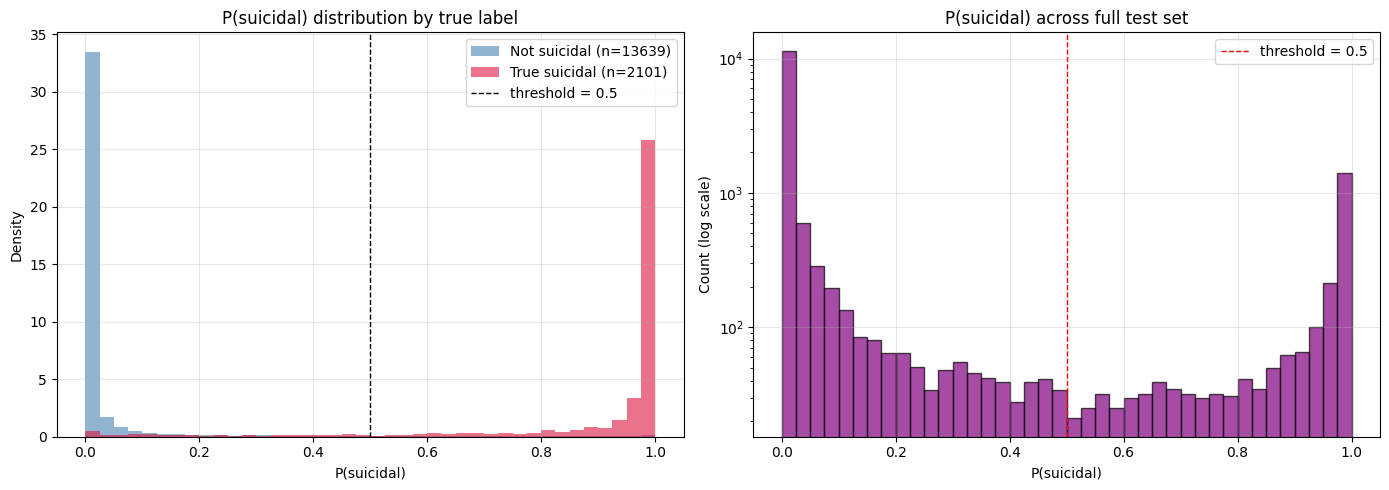


=== Stats for P(suicidal) ===
True suicidal samples (n=2101):
  mean=0.8922  median=0.9908  std=0.2251
  % above 0.5: 91.6%

Other samples (n=13639):
  mean=0.0446  median=0.0024  std=0.1471
  % above 0.5: 3.0%


In [ ]:
import matplotlib.pyplot as plt

def plot_suicidal_probability_distribution(model_path, result_dict, label_col='threeclass_label',
                                            suicidal_class='suicidewatch'):
    """
    Plot the distribution of P(suicidal) across the test set,
    split by true label (suicidal vs not).
    """
    class_names = result_dict['class_names']
    num_labels = len(class_names)

    if suicidal_class not in class_names:
        raise ValueError(f"'{suicidal_class}' not in class names: {class_names}")
    suicidal_idx = class_names.index(suicidal_class)

    # Rebuild model and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Recreate the same test split used in run_experiment
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = work[work[label_col].isin(keep)].reset_index(drop=True)
    le = result_dict['label_encoder']
    work['_y'] = le.transform(work[label_col].astype(str))

    _, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    test_df = test_df.reset_index(drop=True)

    # Tokenize and run inference, collecting P(suicidal)
    enc = tokenizer(test_df['other_posts'].tolist(), max_length=MAX_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ds = TextClassificationDataset(enc, test_df['_y'].values)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.array(all_true)
    suicidal_probs = all_probs[:, suicidal_idx]

    is_suicidal = (all_true == suicidal_idx)
    probs_pos = suicidal_probs[is_suicidal]
    probs_neg = suicidal_probs[~is_suicidal]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overlaid histograms
    bins = np.linspace(0, 1, 41)
    axes[0].hist(probs_neg, bins=bins, alpha=0.6, label=f'Not {suicidal_class} (n={len(probs_neg)})',
                 color='steelblue', density=True)
    axes[0].hist(probs_pos, bins=bins, alpha=0.6, label=f'True {suicidal_class} (n={len(probs_pos)})',
                 color='crimson', density=True)
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[0].set_xlabel(f'P({suicidal_class})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'P({suicidal_class}) distribution by true label')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: log-scale full test set
    axes[1].hist(suicidal_probs, bins=bins, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(f'P({suicidal_class})')
    axes[1].set_ylabel('Count (log scale)')
    axes[1].set_title(f'P({suicidal_class}) across full test set')
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('suicidal_probability_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n=== Stats for P({suicidal_class}) ===')
    print(f'True {suicidal_class} samples (n={len(probs_pos)}):')
    print(f'  mean={probs_pos.mean():.4f}  median={np.median(probs_pos):.4f}  '
          f'std={probs_pos.std():.4f}')
    print(f'  % above 0.5: {(probs_pos >= 0.5).mean() * 100:.1f}%')
    print(f'\nOther samples (n={len(probs_neg)}):')
    print(f'  mean={probs_neg.mean():.4f}  median={np.median(probs_neg):.4f}  '
          f'std={probs_neg.std():.4f}')
    print(f'  % above 0.5: {(probs_neg >= 0.5).mean() * 100:.1f}%')

    return suicidal_probs, all_true


probs, true = plot_suicidal_probability_distribution(
    model_path='best_roberta_threeclass_v3.pt',
    result_dict=result_3class,
    label_col='threeclass_label',
    suicidal_class='suicidal',
)